# BMI Classification — Machine Learning Model
Comparing **Logistic Regression**, **Random Forest**, and **Gradient Boosting** on the BMI dataset.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2 — Load & Explore Data

In [2]:
df = pd.read_csv('bmi.csv')

print('Shape:', df.shape)
print()
print('First 5 rows:')
df.head()

Shape: (500, 4)

First 5 rows:


,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [3]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Descriptive statistics:')
df.describe()

Data types:
Gender    object
Height     int64
Weight     int64
Index      int64
dtype: object

Missing values:
Gender    0
Height    0
Weight    0
Index     0
dtype: int64

Descriptive statistics:


,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


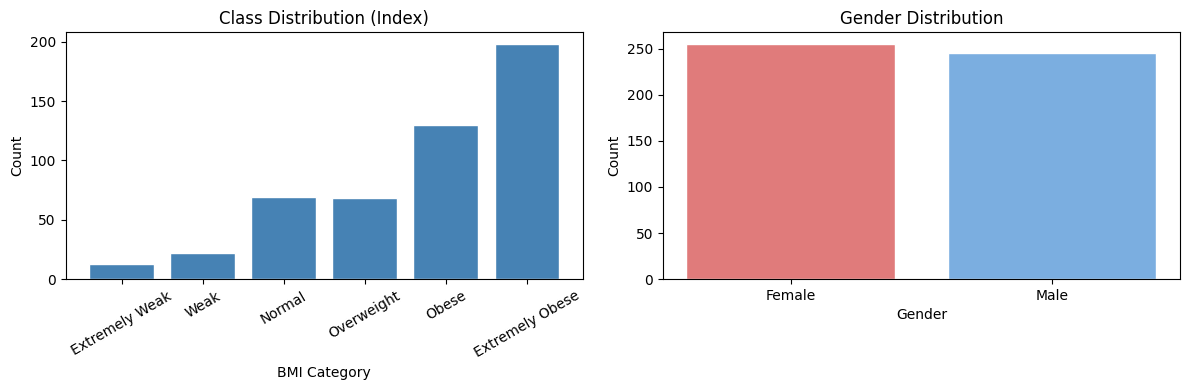

In [4]:
# Class distribution
label_names = {
    0: 'Extremely Weak',
    1: 'Weak',
    2: 'Normal',
    3: 'Overweight',
    4: 'Obese',
    5: 'Extremely Obese'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
counts = df['Index'].value_counts().sort_index()
axes[0].bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Class Distribution (Index)')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['#e07b7b','#7baee0'], edgecolor='white')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

In [5]:
# Encode Gender: Female=0, Male=1
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Features and target
X = df[['Gender', 'Height', 'Weight']]
y = df['Index']

print('Features (X):')
print(X.head())
print()
print('Target (y):')
print(y.head())

Features (X):
   Gender  Height  Weight
0       1     174      96
1       1     189      87
2       0     185     110
3       0     195     104
4       1     149      61

Target (y):
0    4
1    2
2    4
3    3
4    3
Name: Index, dtype: int64


## Step 4 — Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class proportions
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')
print()
print('Class distribution in training set:')
print(y_train.value_counts().sort_index())

Training set : 400 rows
Test set     : 100 rows

Class distribution in training set:
Index
0     10
1     18
2     55
3     54
4    104
5    159
Name: count, dtype: int64


## Step 5 — Train Models

In [7]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Train and store predictions
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'{name:25s} -> Accuracy: {acc:.4f}')

Logistic Regression       -> Accuracy: 0.8400
Random Forest             -> Accuracy: 0.8300
Gradient Boosting         -> Accuracy: 0.8300


## Step 6 — Detailed Classification Reports

In [8]:
target_names = [label_names[i] for i in sorted(label_names)]

for name, res in results.items():
    print(f'========== {name} ==========')
    print(classification_report(y_test, res['preds'], target_names=target_names))
    print()

========== Logistic Regression ==========
                 precision    recall  f1-score   support

 Extremely Weak       1.00      0.67      0.80         3
           Weak       0.43      0.75      0.55         4
         Normal       0.77      0.71      0.74        14
     Overweight       0.69      0.79      0.73        14
          Obese       0.91      0.77      0.83        26
Extremely Obese       0.95      0.97      0.96        39

       accuracy                           0.84       100
      macro avg       0.79      0.78      0.77       100
   weighted avg       0.86      0.84      0.84       100


========== Random Forest ==========
                 precision    recall  f1-score   support

 Extremely Weak       1.00      0.67      0.80         3
           Weak       0.60      0.75      0.67         4
         Normal       0.86      0.86      0.86        14
     Overweight       0.89      0.57      0.70        14
          Obese       0.72      0.88      0.79        26
Extre

## Step 7 — Confusion Matrices

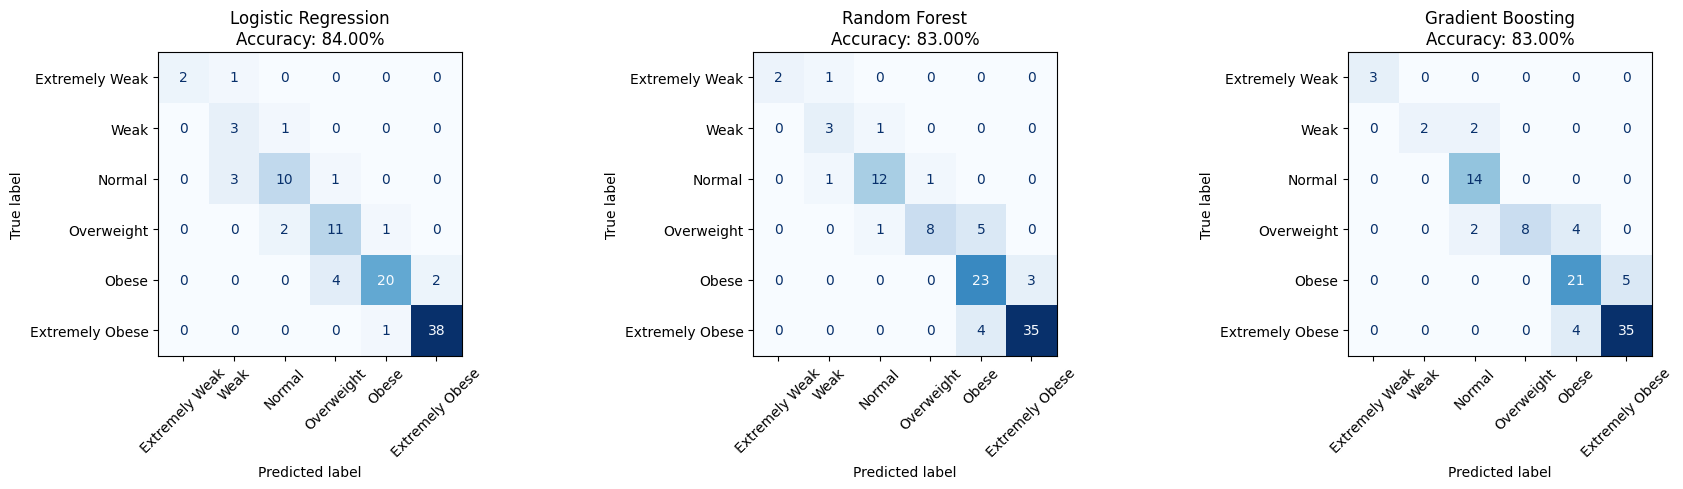

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.2%}')

plt.tight_layout()
plt.show()

## Step 8 — Feature Importance

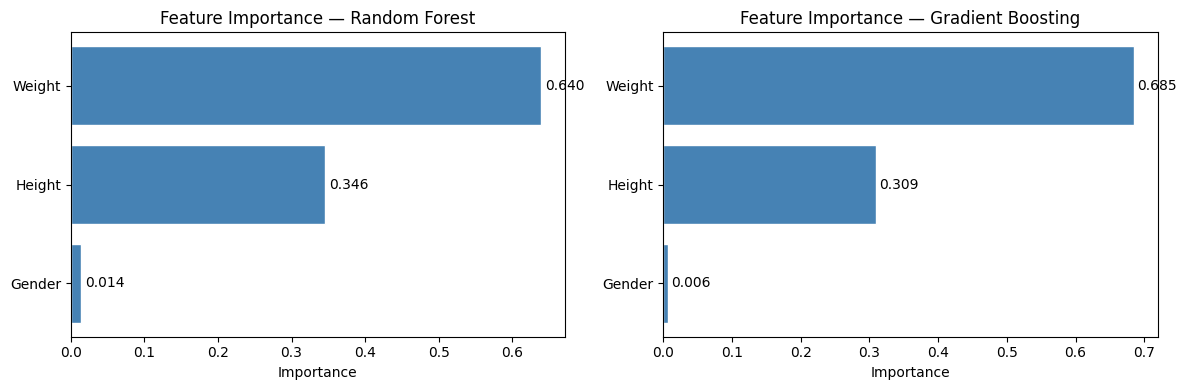

In [10]:
feature_names = ['Gender', 'Height', 'Weight']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    importances = results[model_name]['model'].feature_importances_
    sorted_idx = np.argsort(importances)
    ax.barh(
        [feature_names[i] for i in sorted_idx],
        importances[sorted_idx],
        color='steelblue', edgecolor='white'
    )
    ax.set_title(f'Feature Importance — {model_name}')
    ax.set_xlabel('Importance')
    for i, v in enumerate(importances[sorted_idx]):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 9 — Model Comparison Summary

In [11]:
from sklearn.metrics import f1_score

summary = []
for name, res in results.items():
    macro_f1  = f1_score(y_test, res['preds'], average='macro')
    weighted_f1 = f1_score(y_test, res['preds'], average='weighted')
    summary.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'Macro F1': f"{macro_f1:.4f}",
        'Weighted F1': f"{weighted_f1:.4f}"
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model Accuracy Macro F1 Weighted F1
Logistic Regression   0.8400   0.7691      0.8440
      Random Forest   0.8300   0.7869      0.8288
  Gradient Boosting   0.8300   0.8198      0.8251


## Step 10 — Save Best Model

In [12]:
import joblib

# Save Gradient Boosting (best macro F1)
best_model = results['Gradient Boosting']['model']
joblib.dump(best_model, 'bmi_gradient_boosting_model.pkl')
print('Model saved as bmi_gradient_boosting_model.pkl')

# Example: predict on new data
# Gender: Male=1/Female=0 | Height in cm | Weight in kg
new_data = pd.DataFrame({
    'Gender': [1, 0],
    'Height': [175, 160],
    'Weight': [90, 55]
})

predictions = best_model.predict(new_data)
for i, pred in enumerate(predictions):
    print(f'Person {i+1}: Predicted BMI Category = {pred} ({label_names[pred]})')

Model saved as bmi_gradient_boosting_model.pkl
Person 1: Predicted BMI Category = 3 (Overweight)
Person 2: Predicted BMI Category = 2 (Normal)
